# 2. State & Memory

Deeper understanding of State and Memory in Langgraph.

| Date | User | Change Type | Remarks |  
| ---- | ---- | ----------- | ------- |
| 20/05/26   | Martin | CREATE   | Notebook created for state and memory in Langgraph | 
| 25/05/26   | Martin | UPDATE   | Completed module 2. State, messages and a simple persistent chatbot | 

# Content

* [State](#state)
* [Messages](#messages)
* [Chatbot](#chatbot)

# State

_State Schema:_ Represents the structure and types of data used by the graph. All nodes are expected to communicate with that schema

- `TypedDict` often used as the state schema because represents key value stores
- `dataclass` can also be another way to define a similar schema type 
- `pydantic` provides additional data validation and static type checking during runtime

In [2]:
from typing import Literal, TypedDict, Any
from dataclasses import dataclass
from pydantic import BaseModel, ValidationError, field_validator
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

In [ ]:
# TypedDict
class StateSchema(TypedDict):
    name: str
    mood: Literal["happy", "sad"]

builder = StateGraph(StateSchema)
graph = builder.compile()

graph.invoke({"name": "Martin", "mood": "happy"})

In [ ]:
# Dataclass
@dataclass
class DataclassState:
    name: str
    mood: Literal["happy", "sad"]

builder = StateGraph(DataclassState)
graph = builder.compile()

graph.invoke(DataclassState(name="Martin", mood="sad"))

In [2]:
# Pydantic + validation
class PydanticSchema(BaseModel):
    name: str
    mood: Literal["happy", "sad"]

    @field_validator('mood', mode='after')
    @classmethod
    def ensure_mood(cls, value: Any) -> Any:
        if value not in ["happy", "sad"]:
            raise ValueError("mood should either be 'happy' or 'sad' only")
        return value

try:
    PydanticSchema(name="Martin", mood="mad")
except ValidationError as e:
    print(f"Validation Error: {e}")

Validation Error: 1 validation error for PydanticSchema
mood
  Input should be 'happy' or 'sad' [type=literal_error, input_value='mad', input_type=str]
    For further information visit https://errors.pydantic.dev/2.12/v/literal_error


## State reducers

Defines how state is updated on specific keys/ channels in the state schema

In [3]:
from typing import Annotated
from operator import add

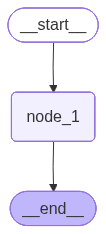

In [4]:
# Define a simple 1 node graph
class State(TypedDict):
    foo: Annotated[list[int], add]  # Reducer function

def node_1(state: State):
    print("=== Node 1 ===")
    return {"foo": [state['foo'][0] + 1]}

builder = StateGraph(State)
builder.add_node("node_1", node_1)
builder.add_edge(START, "node_1")
builder.add_edge("node_1", END)

graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [6]:
graph.invoke({"foo": [1]})

=== Node 1 ===


{'foo': [1, 2]}

Custom reducers are also available to handle more complex cases or unknown data types

In [7]:
def reduce_list(left: list | None, right: list | None) -> list:
    """Safely combine two lists, handling cases where either or both inputs might be
    None

    Args:
        left (list | None): First list to combine, or None
        right (list | None): Second list to combine, or None

    Returns:
        list: A new list containing all elements from both input lists
    """
    if not left:
        left = []
    if not right:
        right = []
    return left + right

class CustomReducerState(TypedDict):
    foo: Annotated[list[str], reduce_list]

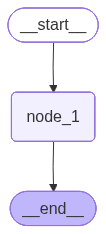

In [8]:
def node_1(state: CustomReducerState):
    print("=== Node 1 ===")
    return {"foo": [2]}

builder = StateGraph(CustomReducerState)
builder.add_node("node_1", node_1)
builder.add_edge(START, "node_1")
builder.add_edge("node_1", END)

graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [11]:
graph.invoke({"foo": [10]})

=== Node 1 ===


{'foo': [10, 2]}

## Multiple schemas

Most graphs only use a single Schema throughout the entire lifecycle, but some instances require multiple schemas

Instances:

- If information between nodes are not to be exposed to the user
- If the input and output schema of the nodes are different

### Private state

To pass information internally as intermediate logic of the graph, but not relevant for the overall graph input or output

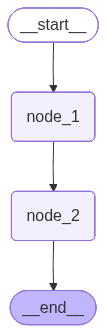

In [22]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

class OverallSchema(TypedDict):
    foo: int

class IntermediateSchema(TypedDict):
    baz: int

# Schema change according to how the nodes are arranged
# Internally the intermediate schema is never observed by the user
def node_1(state: OverallSchema) -> IntermediateSchema:
    return {"baz": state['foo'] + 1}

def node_2(state: IntermediateSchema) -> OverallSchema:
    return {"foo": state['baz'] + 1}

builder = StateGraph(OverallSchema)
builder.add_node("node_1", node_1)
builder.add_node("node_2", node_2)

builder.add_edge(START, "node_1")
builder.add_edge("node_1", "node_2")
builder.add_edge("node_2", END)

graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))


In [23]:
graph.invoke({"foo": 1})

{'foo': 3}

### Input/ Output

Different input and output states. The overall state might contain all in the info, but only shows what is configured in the output state. It provides additional guard to control what is observed by the user in input and output

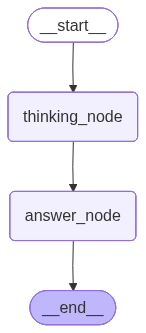

{'answer': 'bye Martin'}

In [24]:
class InputState(TypedDict):
    question: str

class OutputState(TypedDict):
    answer: str

class OverallState(TypedDict):
    question: str
    notes: str
    answer: str

def thinking_node(state: InputState):
    return {"answer": "bye", "notes": "... is martin his name?"}

def answer_node(state: OverallState) -> OutputState:
    return {"answer": "bye Martin"}

graph = StateGraph(OverallState, input_schema=InputState, output_schema=OutputState)
graph.add_node("answer_node", answer_node)
graph.add_node("thinking_node", thinking_node)
graph.add_edge(START, "thinking_node")
graph.add_edge("thinking_node", "answer_node")
graph.add_edge("answer_node", END)

graph = graph.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

graph.invoke({"question":"hi"})

---

# Messages

More messages operations to help control the context the Agent has access to

In [7]:
import os
from dotenv import load_dotenv
from langgraph.graph import MessagesState, StateGraph, START, END
from langgraph.graph.message import add_messages
from langchain_core.messages import AIMessage, HumanMessage, RemoveMessage, trim_messages
from langchain_groq import ChatGroq
from IPython.display import Image, display

load_dotenv()

True

In [ ]:
load_dotenv()
llm = ChatGroq(
    model="llama-3.1-8b-instant",
    api_key=os.getenv("GROQ_API_KEY", "")
)

How to get new information from conversations into context. Using the __SAME__ `id` in each message will overrite the older version and take the later one

In [ ]:
# Add messages
initial_messages = [AIMessage(content="Hello~ how can I assist you?", name="Model", id=1),
                    HumanMessage(
                        content="I'm looking for marine biology nearby?",
                        name="Martin",
                        id=2
                    )]

new_message = HumanMessage(
    content="I'm looking for information about whales",
    name="Martin",
    id=2
)

add_messages(initial_messages, new_message)

In [ ]:
# Delete message
initial_messages.append(
    HumanMessage(content="Can you give me more info?", name="Martin", id=3
))
initial_messages.append(
    AIMessage(content="Can you give me more info?", name="Model", id=4
))

delete_message = [RemoveMessage(id=m.id) for m in initial_messages[:-2]]
delete_message

In [ ]:
add_messages(initial_messages, delete_message)

## Filtering and trimming messages

- Filtering - Remove unwanted messages from the context prior to using the LLM. State remains unchanged, but messages the LLM has access to can change
- Trimming - Shortening messages (e.g max tokens for the LLM)

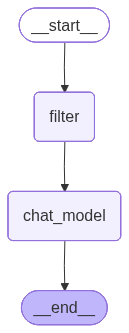

In [39]:
# Filtering - removing unneeded messages
# ---- Nodes ----
def filter_message(state: MessagesState):
    delete_message = [RemoveMessage(id=m.id) for m in state['messages'][:-2]]
    return {'messages': delete_message}

def chat_model_node(state: MessagesState):
    return {'messages': [llm.invoke(state['messages'])]}

# ---- Build Graph ----
# Build graph
builder = StateGraph(MessagesState)
builder.add_node("filter", filter_message)
builder.add_node("chat_model", chat_model_node)
builder.add_edge(START, "filter")
builder.add_edge("filter", "chat_model")
builder.add_edge("chat_model", END)
graph = builder.compile()

# ---- View ----
display(Image(graph.get_graph().draw_mermaid_png()))

In [40]:
messages = [AIMessage("Hi.", name="Bot", id="1")]
messages.append(HumanMessage("Hi.", name="Martin", id="2"))
messages.append(
    AIMessage(
        "So you said you were researching ocean mammals?",
        name="Bot",
        id="3"
    )
)
messages.append(
    HumanMessage(
        "Yes, I know about whales. But what others should I learn about?",
        name="Martin",
        id="4"
    )
)

output = graph.invoke({'messages': messages})
for m in output['messages']:
    m.pretty_print()

================================== Ai Message ==================================
Name: Bot

So you said you were researching ocean mammals?
================================ Human Message =================================
Name: Lance

Yes, I know about whales. But what others should I learn about?
================================== Ai Message ==================================

There are several other fascinating ocean mammals you might want to learn about. Here are a few examples:

1. **Dolphins**: These intelligent, social creatures are closely related to whales. They are known for their playful nature and ability to communicate with each other using clicks and whistles.
2. **Porpoises**: Like dolphins, porpoises are small, toothed cetaceans. However, they are generally more shy and solitary than dolphins.
3. **Manatees**: Also known as sea cows, manatees are large, slow-moving mammals that live in shallow waters in the Caribbean and Gulf of Mexico. They are herbivores and feed on sea

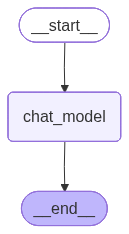

In [8]:
# Trimming - Shorten messages
def chat_model_node(state: MessagesState):
    messages = trim_messages(
        state['messages'],
        max_tokens=100,
        strategy='last',
        token_counter=ChatGroq(
            model="llama-3.1-8b-instant",
            api_key=os.getenv("GROQ_API_KEY", "")
        ),
        allow_partial=True
    )
    return {"messages": [llm.invoke(messages)]}

# Build graph
builder = StateGraph(MessagesState)
builder.add_node("chat_model", chat_model_node)
builder.add_edge(START, "chat_model")
builder.add_edge("chat_model", END)
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

---

# Chatbot

🎯 Goal: Regular chatbot, but summarises the messages in the context to reduce the token usage

Retains a compressed representation of the full conversation rather than just trimming or filtering

In [1]:

import os
from dotenv import load_dotenv
from typing import Literal
from langgraph.graph import MessagesState, StateGraph, START, END
from langchain_core.messages import SystemMessage, HumanMessage, RemoveMessage
from langchain_groq import ChatGroq
from langgraph.checkpoint.memory import MemorySaver
from IPython.display import Image, display

load_dotenv()
llm = ChatGroq(
    model="llama-3.1-8b-instant",
    api_key=os.getenv("GROQ_API_KEY", "")
)

In [2]:
class State(MessagesState):
    summary: str

In [3]:
def chat_model(state: State):
    """
    Chat model that appends the summary before the user messages if it exists
    """
    summary = state.get("summary", "")
    if summary:
        summary_message = f"This is the current summary of the conversation: {summary}"

        # Add the summary message to the existing conversation
        messages = [SystemMessage(content=summary_message)] + state['messages']
    else:
        messages = state['messages']

    output = llm.invoke(messages)
    return {"messages": output}

In [4]:
def summarise_messages(state: State):
    """
    Creates or appends to the summary of the conversation before adding it to the state
    """
    summary = state.get("summary", "")
    if summary:
        new_summary = (
            f"The current summary of the conversation is {summary}"
            "Please extend the summary with the current message above:"
        )
    else:
        new_summary = "Create a summary based on the current messages above:"

    # Only creates the summary
    message_w_summary = state['messages'] + [HumanMessage(content=new_summary)]
    output = llm.invoke(message_w_summary)

    # Delete all but 2 of the most recent messages
    delete_messages = [RemoveMessage(id=m.id) for m in state['messages'][:-2]]
    return {"summary": output.content, "messages": delete_messages}

In [5]:
def should_continue(state: State) -> Literal["summarise_messages", END]:
    """Return the next node to execute"""
    messages = state['messages']

    # Threshold here includes the AI messages
    if len(messages) > 6:
        return "summarise_messages"

    return END

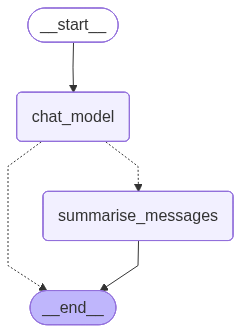

In [6]:
# Define the graph
workflow = StateGraph(State)

workflow.add_node("chat_model", chat_model)
workflow.add_node("summarise_messages", summarise_messages)

workflow.add_edge(START, "chat_model")
workflow.add_conditional_edges("chat_model", should_continue)
workflow.add_edge("summarise_messages", END)

memory = MemorySaver()
graph = workflow.compile(checkpointer=memory)
display(Image(graph.get_graph().draw_mermaid_png()))

Theads help to save the conversation

In [7]:
# Conversation
config = {"configurable": {"thread_id": "1"}}

input_message = HumanMessage(content="hi! I'm Martin!")
output = graph.invoke({"messages": [ input_message ]}, config)
for m in output['messages'][-1:]:
    m.pretty_print()

input_message = HumanMessage(content="what's my name?")
output = graph.invoke({"messages": [ input_message ]}, config)
for m in output['messages'][-1:]:
    m.pretty_print()

input_message = HumanMessage(content="i like the golden state warriors")
output = graph.invoke({"messages": [ input_message ]}, config)
for m in output['messages'][-1:]:
    m.pretty_print()

Failed to multipart ingest runs: langsmith.utils.LangSmithError: Failed to POST https://apac.api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://apac.api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


================================== Ai Message ==================================

Hello Martin, it's nice to meet you. Is there something I can help you with or would you like to chat?
================================== Ai Message ==================================

Your name is Martin.
================================== Ai Message ==================================

The Golden State Warriors are a beloved NBA team with a lot of history and success, especially in the 2010s with their dynasty led by Stephen Curry, Klay Thompson, and Draymond Green. Who's your favorite player on the Warriors, past or present?


Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://apac.api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://apac.api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


In [8]:
# See that there is no summary created yet
graph.get_state(config).values.get("summary", "")

''

In [9]:
# Add a few more messages
input_message = HumanMessage(content="who is the greatest player on that team?")
output = graph.invoke({"messages": [ input_message ]}, config)
for m in output['messages'][-1:]:
    m.pretty_print()

input_message = HumanMessage(content="what's something interesting about that player?")
output = graph.invoke({"messages": [ input_message ]}, config)
for m in output['messages'][-1:]:
    m.pretty_print()

input_message = HumanMessage(content="what is their greatest accomplishment?")
output = graph.invoke({"messages": [ input_message ]}, config)
for m in output['messages'][-1:]:
    m.pretty_print()

Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://apac.api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://apac.api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


================================== Ai Message ==================================

That's a subjective question, but many fans and analysts would argue that Stephen Curry is the greatest player in Golden State Warriors history. He's a two-time NBA MVP, two-time NBA champion, and has broken numerous records throughout his career. His shooting ability, combined with his clutch performances and leadership, have made him a legendary figure in the NBA.

However, some people might also argue that Wilt Chamberlain, who played for the Warriors in the 1960s, was the greatest player in team history. Chamberlain is the NBA's all-time leading scorer and had an incredible career, including two NBA championships with the Warriors.

Ultimately, the answer to this question depends on personal opinion and how one weighs different aspects of a player's career.


Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://apac.api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://apac.api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


================================== Ai Message ==================================

One interesting thing about Stephen Curry is his incredible shooting ability, particularly from beyond the 3-point line. He's a career 43.8% 3-point shooter, which is one of the highest rates in NBA history. However, what's even more impressive is that he was born with a condition called heterochromia iridum, which affects the color of his eyes, and he also has a relatively small stature for an NBA player, standing at 6 feet 3 inches.

Despite these factors, Curry has developed a shooting technique that allows him to shoot from anywhere on the court with incredible accuracy. His ability to make shots from beyond the arc has revolutionized the game, and he's been a key factor in the Warriors' success during their championship runs.

Another interesting fact about Curry is that he's a self-taught shooter. He grew up playing with his father, Dell Curry, who played in the NBA, and Stephen has said that he lea

Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://apac.api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://apac.api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


================================== Ai Message ==================================

The Golden State Warriors' greatest accomplishment is likely their 2017 NBA championship run, where they became the first team in NBA history to win 67 games in a season and then win an NBA championship. They swept the Portland Trail Blazers in the first round of the playoffs, then defeated the Utah Jazz in the second round, and finally defeated the Houston Rockets in the Western Conference Finals.

In the NBA Finals, they faced off against the Cleveland Cavaliers, who were seeking to come back from a 3-1 deficit to win the series. However, the Warriors prevailed, winning the series 4-1 and capturing their second championship in three years.

This team was led by Stephen Curry, who was named the NBA Finals MVP, and was also known for its strong bench, including players like Andre Iguodala, Shaun Livingston, and Klay Thompson. The Warriors' 2017 championship was a testament to the team's depth, talent, and

Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://apac.api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://apac.api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


In [10]:
# Now there's a summary
print(graph.get_state(config).values.get("summary", ""))

Here's a summary of our conversation:

- We had a brief introduction where I learned that your name is Martin.
- You mentioned that you like the Golden State Warriors, an NBA team with a rich history and success.
- We discussed your favorite player on the Warriors (although you didn't specify one) and who might be considered the greatest player in Warriors history.
- I suggested that Stephen Curry, a two-time NBA champion and MVP, is often considered the greatest player in Warriors history due to his impressive shooting skills and clutch performances.
- I also mentioned Wilt Chamberlain, a legendary player who played for the Warriors in the 1960s and is the NBA's all-time leading scorer.


## Storing memory in external DB

Allows chat memory to persist in an external DB

In [6]:
import sqlite3
from langgraph.checkpoint.sqlite import SqliteSaver

# In memory
conn = sqlite3.connect(":memory:")

In [7]:
db_path = "state/example.db"
conn = sqlite3.connect(db_path, check_same_thread=False)

In [8]:
memory = SqliteSaver(conn)

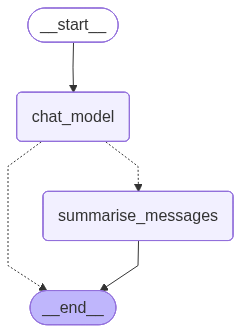

In [9]:
# Define the graph
workflow = StateGraph(State)

workflow.add_node("chat_model", chat_model)
workflow.add_node("summarise_messages", summarise_messages)

workflow.add_edge(START, "chat_model")
workflow.add_conditional_edges("chat_model", should_continue)
workflow.add_edge("summarise_messages", END)

graph = workflow.compile(checkpointer=memory)
display(Image(graph.get_graph().draw_mermaid_png()))

In [10]:
# Invoke the messages
config = {"configurable": {"thread_id": "1"}}

input_message = HumanMessage(content="hi! I'm Martin!")
output = graph.invoke({"messages": [ input_message ]}, config)
for m in output['messages'][-1:]:
    m.pretty_print()

input_message = HumanMessage(content="what's my name?")
output = graph.invoke({"messages": [ input_message ]}, config)
for m in output['messages'][-1:]:
    m.pretty_print()

input_message = HumanMessage(content="i like the golden state warriors")
output = graph.invoke({"messages": [ input_message ]}, config)
for m in output['messages'][-1:]:
    m.pretty_print()

input_message = HumanMessage(content="who is the greatest player on that team?")
output = graph.invoke({"messages": [ input_message ]}, config)
for m in output['messages'][-1:]:
    m.pretty_print()

Failed to multipart ingest runs: langsmith.utils.LangSmithError: Failed to POST https://apac.api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://apac.api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


================================== Ai Message ==================================

Hi Martin. It's nice to meet you. Is there something on your mind, or would you like to chat about something in particular?
================================== Ai Message ==================================

Your name is Martin.
================================== Ai Message ==================================

The Golden State Warriors are a great team with a rich history in the NBA. They've had some incredible seasons and players, including Stephen Curry, who's widely regarded as one of the greatest shooters in NBA history. Are you a fan of a specific era of the Warriors, or do you have a favorite player?
================================== Ai Message ==================================

Opinions on this can vary depending on personal taste and generational differences. However, according to many fans, analysts, and accolades, Stephen Curry is often considered the greatest player in Golden State Warriors hist

Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://apac.api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://apac.api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


In [11]:
# Current state of graph
graph_state = graph.get_state(config)
graph_state

StateSnapshot(values={'messages': [HumanMessage(content='who is the greatest player on that team?', additional_kwargs={}, response_metadata={}, id='abe50a39-c00a-45da-94ad-7cb23ea434bb'), AIMessage(content="Opinions on this can vary depending on personal taste and generational differences. However, according to many fans, analysts, and accolades, Stephen Curry is often considered the greatest player in Golden State Warriors history. He's a two-time NBA champion, two-time NBA MVP, and has won multiple scoring titles. His incredible shooting ability, combined with his clutch performances and leadership, make a strong case for him being the greatest Warriors player of all time.\n\nThat being said, other notable players like Wilt Chamberlain, Rick Barry, and Klay Thompson also had incredible careers with the Warriors and could be considered among the greatest. But if I had to give you a general answer, Stephen Curry is often the name that comes up in this conversation.", additional_kwargs=

## Persisting state

Restart the notebook here

In [10]:
# Reloaded state
config = {"configurable": {"thread_id": "1"}}
graph_state = graph.get_state(config)
graph_state

StateSnapshot(values={'messages': [HumanMessage(content='who is the greatest player on that team?', additional_kwargs={}, response_metadata={}, id='abe50a39-c00a-45da-94ad-7cb23ea434bb'), AIMessage(content="Opinions on this can vary depending on personal taste and generational differences. However, according to many fans, analysts, and accolades, Stephen Curry is often considered the greatest player in Golden State Warriors history. He's a two-time NBA champion, two-time NBA MVP, and has won multiple scoring titles. His incredible shooting ability, combined with his clutch performances and leadership, make a strong case for him being the greatest Warriors player of all time.\n\nThat being said, other notable players like Wilt Chamberlain, Rick Barry, and Klay Thompson also had incredible careers with the Warriors and could be considered among the greatest. But if I had to give you a general answer, Stephen Curry is often the name that comes up in this conversation.", additional_kwargs=

In [ ]:
%load_ext watermark
%watermark